# 벡터화·임베딩 전체 실습

## 전체 흐름

```text
책 제목 데이터 준비
→ TF-IDF 벡터화
→ SentenceTransformer 로컬 임베딩
→ TSV 저장
→ 임베딩 히트맵
→ PCA 2차원 시각화
→ 코사인 유사도 분석
→ 특정 책과 유사한 책 검색
→ 새로운 문장으로 의미 검색
→ TF-IDF 검색과 임베딩 검색 비교
```

이 노트북은 OpenAI API를 사용하지 않습니다.

- API 키 필요 없음
- API 비용 없음
- 최초 실행 시 Hugging Face에서 임베딩 모델을 다운로드하기 위해 인터넷 연결 필요

In [1]:
# ============================================================
# 1. 필요한 라이브러리 설치
# ============================================================

!pip -q install sentence-transformers
!pip -q install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.4 MB/s eta 0:00:00


In [2]:
# ============================================================
# 2. 라이브러리 불러오기
# ============================================================

import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [3]:
# ============================================================
# 3. 분석할 텍스트 데이터 준비
# ============================================================

texts = [
    "혼자 공부하는 머신러닝+딥러닝",
    "밑바닥부터 시작하는 딥러닝 1",
    "혼자 공부하는 컴퓨터 구조+운영체제",
    "핸즈온 머신러닝",
    "파이썬 머신러닝 완벽 가이드",
    "Do it! 딥러닝 입문",
    "모두의 딥러닝",
    "AI를 위한 필수 수학",
    "딥러닝 파이토치 교과서",
    "케라스 창시자에게 배우는 딥러닝",
    "밑바닥부터 시작하는 딥러닝 2",
    "밑바닥부터 시작하는 딥러닝 3",
    "실전 시계열 분석",
    "파이썬을 활용한 머신러닝 쿡북",
    "파이썬 딥러닝 텐서플로",
    "혼자 공부하는 파이썬",
    "점프 투 파이썬",
    "파이썬 코딩 도장",
    "파이썬으로 배우는 알고리즘 트레이딩",
    "파이썬 데이터 분석",
    "이것이 데이터 분석이다",
    "파이썬 라이브러리를 활용한 데이터 분석",
    "데이터 과학을 위한 통계",
    "데이터 분석가의 숫자유감",
    "혼자 공부하는 SQL",
    "SQL 첫걸음",
    "이것이 MySQL이다",
    "친절한 SQL 튜닝",
    "SQL 전문가 가이드",
    "데이터베이스 개론",
    "혼자 공부하는 네트워크",
    "그림으로 배우는 네트워크 원리",
    "성공과 실패를 결정하는 1%의 네트워크 원리",
    "후니의 쉽게 쓴 시스코 네트워킹",
    "TCP/IP 완벽 가이드",
    "모던 리눅스 교과서",
    "리눅스 커널의 구조와 원리",
    "그림으로 배우는 리눅스 구조",
    "모두의 리눅스",
    "이것이 우분투 리눅스다",
    "그림으로 배우는 도커",
    "한 권으로 배우는 도커 & 쿠버네티스",
    "쿠버네티스 입문",
    "컨테이너 인프라 환경 구축을 위한 쿠버네티스/도커",
    "플랫폼 엔지니어링",
    "혼자 공부하는 자바",
    "이것이 자바다",
    "자바의 정석",
    "혼자 공부하는 C언어",
    "C언어 코딩 도장"
]

print("전체 텍스트 개수:", len(texts))

display(
    pd.DataFrame(
        {
            "번호": range(1, len(texts) + 1),
            "책 제목": texts
        }
    )
)

전체 텍스트 개수: 50


,번호,책 제목
0,1,혼자 공부하는 머신러닝+딥러닝
1,2,밑바닥부터 시작하는 딥러닝 1
2,3,혼자 공부하는 컴퓨터 구조+운영체제
3,4,핸즈온 머신러닝
4,5,파이썬 머신러닝 완벽 가이드
5,6,Do it! 딥러닝 입문
6,7,모두의 딥러닝
7,8,AI를 위한 필수 수학
8,9,딥러닝 파이토치 교과서
9,10,케라스 창시자에게 배우는 딥러닝


In [4]:
# ============================================================
# 4. TF-IDF 벡터화
# ============================================================

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF 행렬 크기:", tfidf_matrix.shape)
print("추출된 단어 수:", len(feature_names))

print("\n추출된 단어 일부:")
print(feature_names[:30])

TF-IDF 행렬 크기: (50, 87)
추출된 단어 수: 87

추출된 단어 일부:
['ai를' 'c언어' 'do' 'ip' 'it' 'mysql이다' 'sql' 'tcp' '가이드' '개론' '결정하는' '공부하는'
 '과학을' '교과서' '구조' '구조와' '구축을' '권으로' '그림으로' '네트워크' '네트워킹' '데이터' '데이터베이스'
 '도장' '도커' '딥러닝' '라이브러리를' '리눅스' '리눅스다' '머신러닝']


In [5]:
# ============================================================
# 5. TF-IDF 결과를 DataFrame으로 확인
# ============================================================

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=texts
)

display(
    tfidf_df.style.background_gradient(
        cmap="Blues"
    )
)

,ai를,c언어,do,ip,it,mysql이다,sql,tcp,가이드,개론,결정하는,공부하는,과학을,교과서,구조,구조와,구축을,권으로,그림으로,네트워크,네트워킹,데이터,데이터베이스,도장,도커,딥러닝,라이브러리를,리눅스,리눅스다,머신러닝,모던,모두의,밑바닥부터,배우는,분석,분석가의,분석이다,성공과,수학,숫자유감,쉽게,시계열,시스코,시작하는,실전,실패를,알고리즘,엔지니어링,완벽,우분투,운영체제,원리,위한,이것이,인프라,입문,자바,자바다,자바의,전문가,점프,정석,창시자에게,첫걸음,친절한,커널의,컨테이너,컴퓨터,케라스,코딩,쿠버네티스,쿡북,텐서플로,통계,튜닝,트레이딩,파이썬,파이썬으로,파이썬을,파이토치,플랫폼,필수,핸즈온,혼자,환경,활용한,후니의
혼자 공부하는 머신러닝+딥러닝,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.487581,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.449437,0.000000,0.000000,0.000000,0.567922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.487581,0.000000,0.000000,0.000000
밑바닥부터 시작하는 딥러닝 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.464393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.626234,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.626234,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
혼자 공부하는 컴퓨터 구조+운영체제,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.348738,0.000000,0.000000,0.468657,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.518230,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.518230,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.348738,0.000000,0.000000,0.000000
핸즈온 머신러닝,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.616902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.787040,0.000000,0.000000,0.000000,0.000000
파이썬 머신러닝 완벽 가이드,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.520285,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.487540,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

In [6]:
# ============================================================
# 6. 각 책 제목에서 TF-IDF 값이 높은 단어 확인
# ============================================================

def get_top_tfidf_words(document_index, top_n=5):
    vector = tfidf_matrix[
        document_index
    ].toarray()[0]

    top_indices = np.argsort(
        vector
    )[::-1][:top_n]

    results = []

    for index in top_indices:
        if vector[index] > 0:
            results.append(
                {
                    "단어": feature_names[index],
                    "TF-IDF": round(
                        float(vector[index]),
                        4
                    )
                }
            )

    return pd.DataFrame(results)


sample_index = 0

print("선택한 책 제목:")
print(texts[sample_index])

display(
    get_top_tfidf_words(
        sample_index,
        top_n=10
    )
)

선택한 책 제목:
혼자 공부하는 머신러닝+딥러닝


,단어,TF-IDF
0,머신러닝,0.5679
1,공부하는,0.4876
2,혼자,0.4876
3,딥러닝,0.4494


In [7]:
# ============================================================
# 7. API 키 없는 로컬 임베딩 모델 불러오기
# ============================================================

embedding_model_name = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

embedding_model = SentenceTransformer(
    embedding_model_name
)

print("임베딩 모델 로드 완료")
print("사용 모델:", embedding_model_name)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

임베딩 모델 로드 완료
사용 모델: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [8]:
# ============================================================
# 8. 전체 책 제목 임베딩 생성
# ============================================================

embedding_array = embedding_model.encode(
    texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

metadata = texts.copy()

print("임베딩 생성 완료")
print("임베딩 배열 크기:", embedding_array.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

임베딩 생성 완료
임베딩 배열 크기: (50, 384)


In [9]:
# ============================================================
# 9. 첫 번째 책 제목의 임베딩 일부 확인
# ============================================================

print("책 제목:")
print(texts[0])

print("\n임베딩 전체 길이:")
print(len(embedding_array[0]))

print("\n임베딩 앞의 숫자 20개:")
print(
    embedding_array[0][:20]
)

책 제목:
혼자 공부하는 머신러닝+딥러닝

임베딩 전체 길이:
384

임베딩 앞의 숫자 20개:
[ 0.01228303  0.03778896 -0.01997511  0.02518842 -0.01808608 -0.01120718
 -0.00329346  0.00939399  0.01009891 -0.04112752  0.02746958  0.02014132
  0.04119292 -0.0261034   0.0246833  -0.03049352 -0.01689776  0.0440005
 -0.01737143 -0.03974968]


In [10]:
# ============================================================
# 10. 임베딩과 메타데이터 TSV 저장
# ============================================================

with open(
    "embeddings.tsv",
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(
        file,
        delimiter="\t"
    )

    for embedding in embedding_array:
        writer.writerow(embedding)


with open(
    "metadata.tsv",
    "w",
    encoding="utf-8"
) as file:

    for text in metadata:
        file.write(text + "\n")


print("저장 완료:")
print("- embeddings.tsv")
print("- metadata.tsv")

저장 완료:
- embeddings.tsv
- metadata.tsv


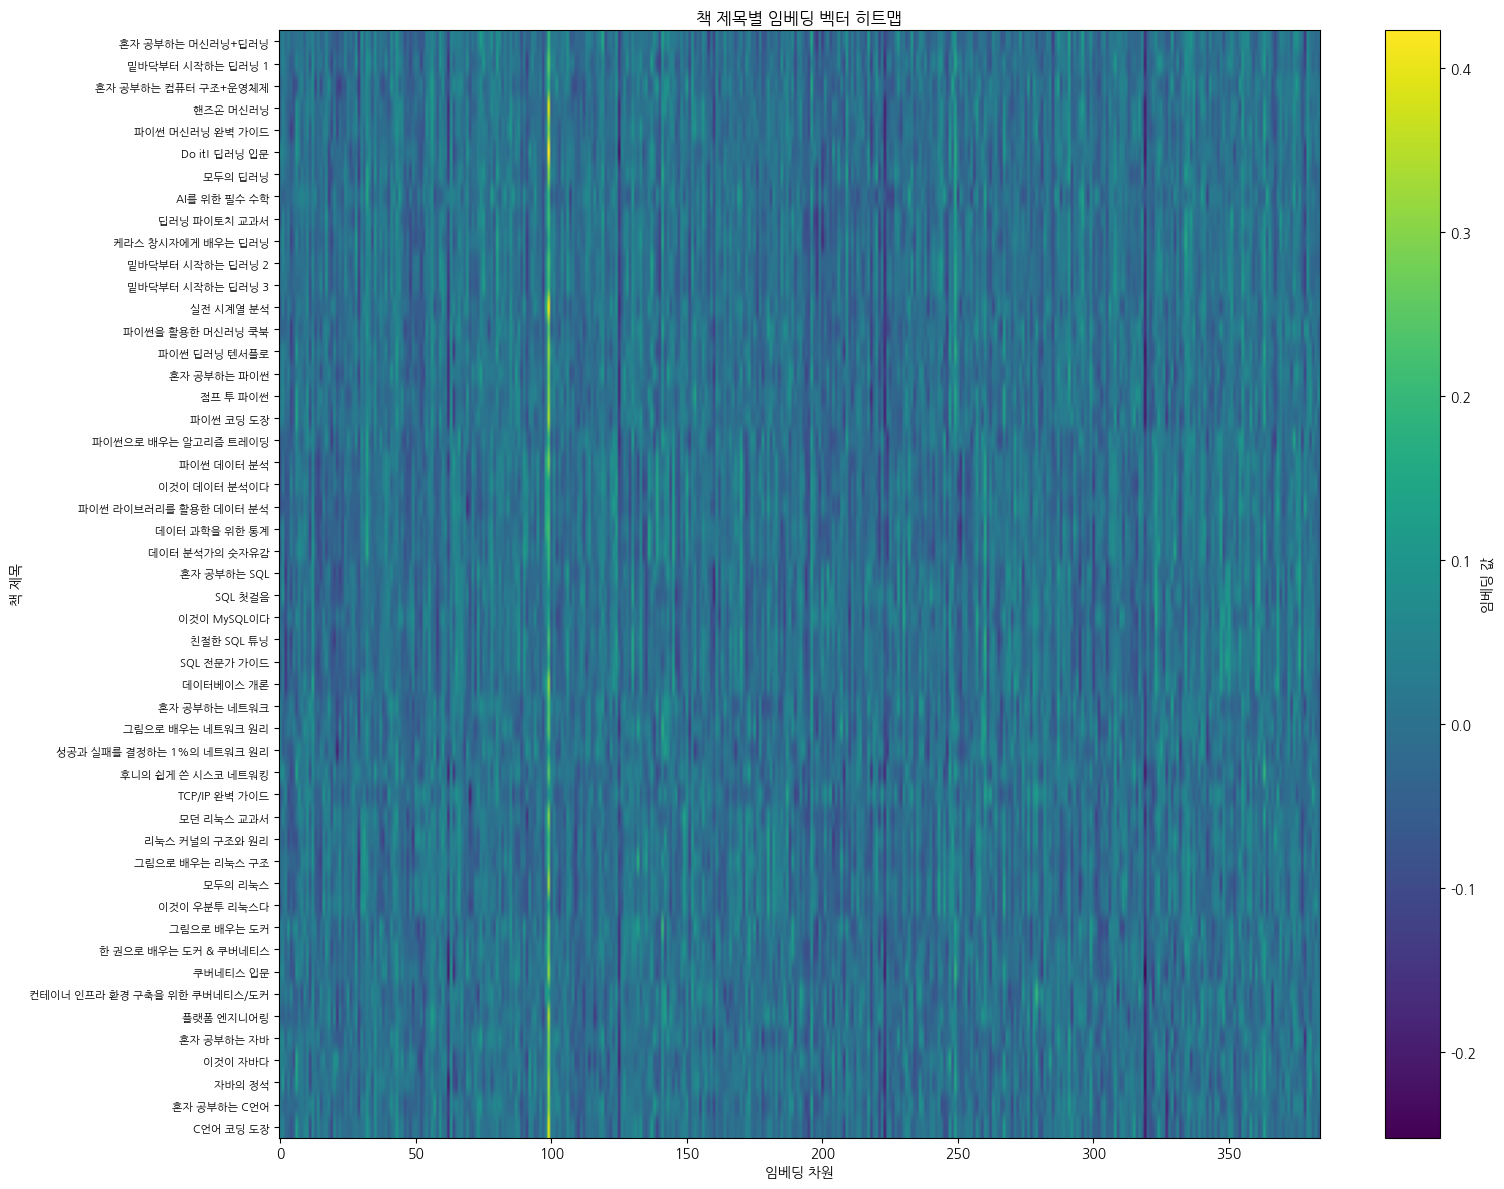

In [11]:
# ============================================================
# 11. 임베딩 벡터 히트맵
# ============================================================

plt.figure(
    figsize=(16, 12)
)

image = plt.imshow(
    embedding_array,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(
    image,
    label="임베딩 값"
)

plt.yticks(
    ticks=np.arange(len(texts)),
    labels=texts,
    fontsize=8
)

plt.xlabel("임베딩 차원")
plt.ylabel("책 제목")

plt.title(
    "책 제목별 임베딩 벡터 히트맵"
)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 12. PCA를 이용한 임베딩 차원 축소
# ============================================================

pca = PCA(
    n_components=2
)

reduced_embeddings = pca.fit_transform(
    embedding_array
)

print(
    "PCA 결과 크기:",
    reduced_embeddings.shape
)

print(
    "두 주성분의 설명 분산 비율:",
    pca.explained_variance_ratio_
)

print(
    "설명 분산 비율 합계:",
    pca.explained_variance_ratio_.sum()
)

PCA 결과 크기: (50, 2)
두 주성분의 설명 분산 비율: [0.21007802 0.11012606]
설명 분산 비율 합계: 0.32020408


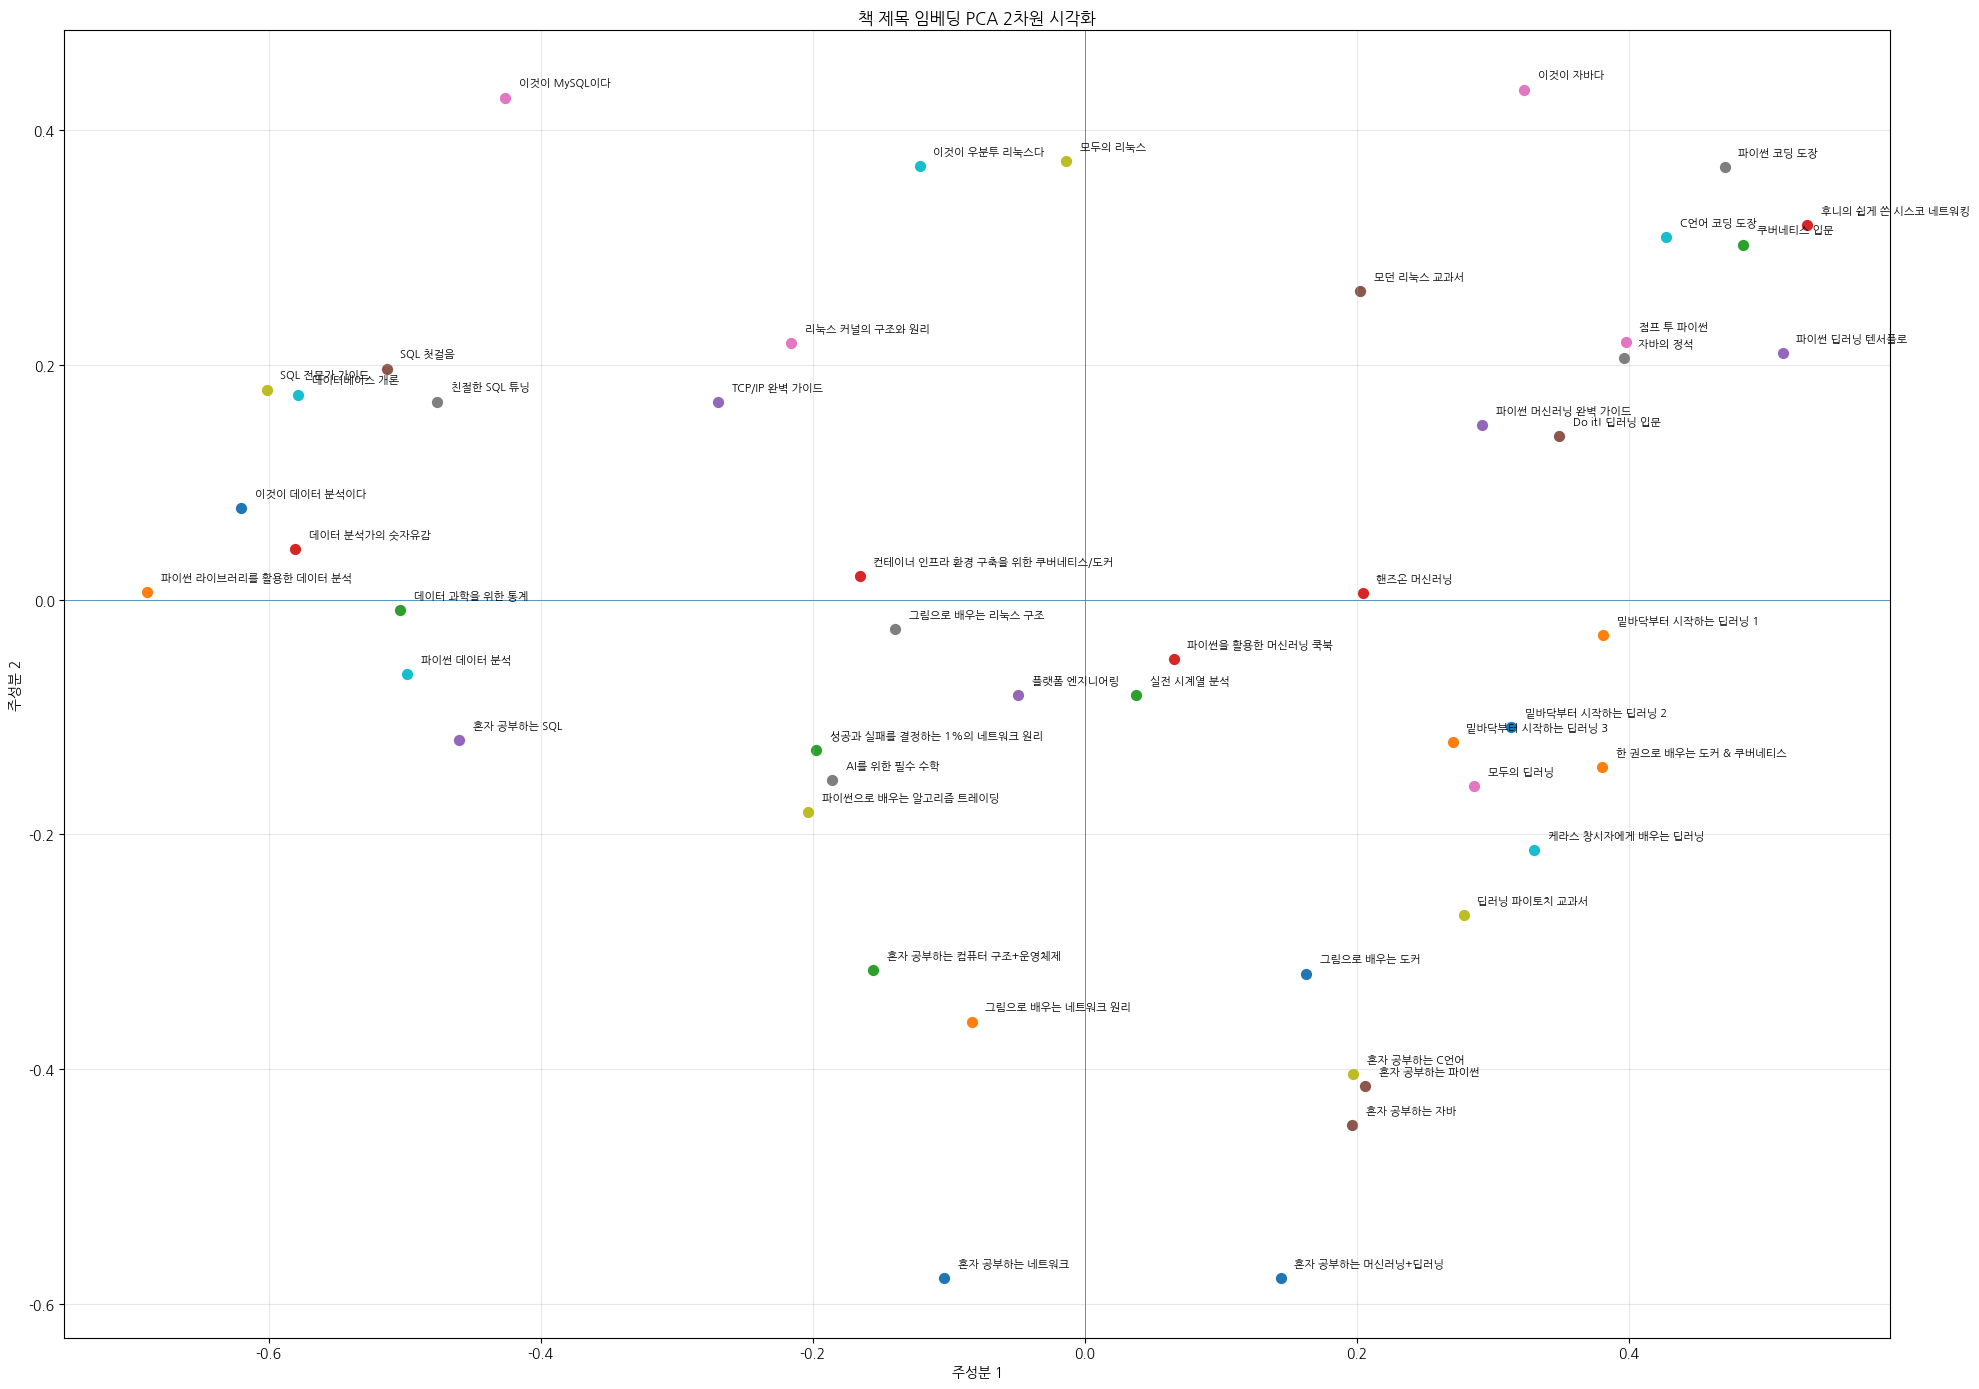

In [13]:
# ============================================================
# 13. PCA 2차원 시각화
# ============================================================

plt.figure(
    figsize=(20, 14)
)

for index, title in enumerate(texts):

    x = reduced_embeddings[index, 0]
    y = reduced_embeddings[index, 1]

    plt.scatter(
        x,
        y,
        s=50
    )

    plt.text(
        x + 0.01,
        y + 0.01,
        title,
        fontsize=8
    )

plt.axhline(
    y=0,
    linewidth=0.5
)

plt.axvline(
    x=0,
    linewidth=0.5
)

plt.xlabel("주성분 1")
plt.ylabel("주성분 2")

plt.title(
    "책 제목 임베딩 PCA 2차원 시각화"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 14. 전체 책 제목 간 코사인 유사도 계산
# ============================================================

similarity_matrix = cosine_similarity(
    embedding_array
)

print(
    "유사도 행렬 크기:",
    similarity_matrix.shape
)

display(
    pd.DataFrame(
        similarity_matrix,
        index=texts,
        columns=texts
    ).round(3)
)

유사도 행렬 크기: (50, 50)


,혼자 공부하는 머신러닝+딥러닝,밑바닥부터 시작하는 딥러닝 1,혼자 공부하는 컴퓨터 구조+운영체제,핸즈온 머신러닝,파이썬 머신러닝 완벽 가이드,Do it! 딥러닝 입문,모두의 딥러닝,AI를 위한 필수 수학,딥러닝 파이토치 교과서,케라스 창시자에게 배우는 딥러닝,밑바닥부터 시작하는 딥러닝 2,밑바닥부터 시작하는 딥러닝 3,실전 시계열 분석,파이썬을 활용한 머신러닝 쿡북,파이썬 딥러닝 텐서플로,혼자 공부하는 파이썬,점프 투 파이썬,파이썬 코딩 도장,파이썬으로 배우는 알고리즘 트레이딩,파이썬 데이터 분석,이것이 데이터 분석이다,파이썬 라이브러리를 활용한 데이터 분석,데이터 과학을 위한 통계,데이터 분석가의 숫자유감,혼자 공부하는 SQL,SQL 첫걸음,이것이 MySQL이다,친절한 SQL 튜닝,SQL 전문가 가이드,데이터베이스 개론,혼자 공부하는 네트워크,그림으로 배우는 네트워크 원리,성공과 실패를 결정하는 1%의 네트워크 원리,후니의 쉽게 쓴 시스코 네트워킹,TCP/IP 완벽 가이드,모던 리눅스 교과서,리눅스 커널의 구조와 원리,그림으로 배우는 리눅스 구조,모두의 리눅스,이것이 우분투 리눅스다,그림으로 배우는 도커,한 권으로 배우는 도커 & 쿠버네티스,쿠버네티스 입문,컨테이너 인프라 환경 구축을 위한 쿠버네티스/도커,플랫폼 엔지니어링,혼자 공부하는 자바,이것이 자바다,자바의 정석,혼자 공부하는 C언어,C언어 코딩 도장
혼자 공부하는 머신러닝+딥러닝,1.000,0.667,0.645,0.564,0.491,0.518,0.744,0.373,0.758,0.682,0.687,0.680,0.497,0.522,0.503,0.798,0.373,0.323,0.453,0.344,0.242,0.210,0.312,0.264,0.504,0.157,0.082,0.301,0.198,0.249,0.735,0.476,0.384,0.313,0.087,0.388,0.228,0.332,0.244,0.215,0.475,0.611,0.351,0.183,0.358,0.812,0.231,0.307,0.754,0.370
밑바닥부터 시작하는 딥러닝 1,0.667,1.000,0.383,0.636,0.698,0.684,0.817,0.304,0.775,0.766,0.953,0.923,0.539,0.551,0.854,0.544,0.638,0.705,0.432,0.303,0.224,0.156,0.289,0.252,0.289,0.273,0.209,0.320,0.221,0.307,0.421,0.440,0.390,0.692,0.158,0.599,0.321,0.341,0.377,0.321,0.420,0.691,0.663,0.210,0.370,0.509,0.544,0.516,0.516,0.714
혼자 공부하는 컴퓨터 구조+운영체제,0.645,0.383,1.000,0.530,0.480,0.303,0.381,0.294,0.431,0.395,0.371,0.383,0.402,0.530,0.298,0.622,0.220,0.241,0.394,0.395,0.294,0.438,0.308,0.267,0.477,0.164,0.144,0.272,0.251,0.389,0.659,0.389,0.356,0.201,0.267,0.481,0.561,0.532,0.479,0.497,0.255,0.400,0.218,0.382,0.522,0.602,0.142,0.207,0.601,0.283
핸즈온 머신러닝,0.564,0.636,0.530,1.000,0.836,0.620,0.581,0.472,0.575,0.563,0.586,0.586,0.572,0.755,0.671,0.532,0.640,0.630,0.556,0.371,0.287,0.237,0.348,0.317,0.267,0.198,0.238,0.330,0.253,0.326,0.386,0.449,0.366,0.567,0.259,0.570,0.366,0.399,0.424,0.385,0.460,0.618,0.595,0.393,0.633,0.476,0.486,0.495,0.483,0.646
파이썬 머신러닝 완벽 가이드,0.491,0.698,0.480,0.836,1.000,0.631,0.620,0.416,0.630,0.621,0.624,0.617,0.573,0.795,0.816,0.593,0.727,0.786,0.541,0.383,0.231,0.255,0.299,0.242,0.265,0.230,0.306,0.385,0.282,0.327,0.311,0.418,0.321,0.721,0.266,0.672,0.366,0.415,0.479,0.445,0.451,0.675,0.671,0.366,0.554,0.446,0.566,0.541,0.449,0.747
Do it! 딥러닝 입문,0.518,0.684,0.303,0.620,0.631,1.000,0.711,0.247,0.575,0.559,0.656,0.634,0.536,0.495,0.728,0.539,0.714,0.689,0.305,0.275,0.226,0.106,0.278,0.234,0.270,0.203,0.306,0.339,0.198,0.283,0.327,0.336,0.361,0.632,0.085,0.515,0.241,0.253,0.461,0.351,0.422,0.588,0.709,0.207,0.357,0.528,0.687,0.639,0.479,0.693
모두의 딥러닝,0.744,0.817,0.381,0.581,0.620,0.711,1.000,0.324,0.817,0.796,0.811,0.822,0.562,0.552,0.727,0.550,0.567,0.557,0.468,0.353,0.270,0.196,0.332,0.299,0.287,0.180,0.212,0.388,0.243,0.307,0.457,0.510,0.350,0.509,0.131,0.477,0.275,0.357,0.435,0.292,0.508,0.640,0.547,0.157,0.348,0.520,0.490,0.515,0.518,0.589
AI를 위한 필수 수학,0.373,0.304,0.294,0.472,0.416,0.247,0.324,1.000,0.396,0.320,0.324,0.329,0.473,0.447,0.219,0.289,0.265,0.186,0.590,0.395,0.332,0.227,0.367,0.426,0.208,0.175,0.159,0.304,0.250,0.252,0.242,0.378,0.245,0.105,0.123,0.278,0.221,0.320,0.164,0.205,0.353,0.324,0.183,0.184,0.332,0.248,0.150,0.218,0.230,0.240
딥러닝 파이토치 교과서,0.758,0.775,0.431,0.575,0.630,0.575,0.817,0.396,1.000,0.834,0.787,0.791,0.646,0.618,0.700,0.643,0.541,0.509,0.483,0.402,0.230,0.247,0.333,0.253,0.307,0.164,0.110,0.362,0.276,0.332,0.475,0.510,0.270,0.503,0.114,0.622,0.281,0.406,0.282,0.273,0.556,0.785,0.532,0.202,0.327,0.551,0.387,0.502,0.561,0.539
케라스 창시자에게 배우는 딥러닝,0.682,0.766,0.395,0.563,0.621,0.559,0.796,0.320,0.834,1.000,0.751,0.752,0.538,0.634,0.691,0.555,0.547,0.544,0.552,0.302,0.156,0.167,0.247,0.209,0.243,0.164,0.105,0.336,0.220,0.227,0.409,0.526,0.292,0.547,0.077,0.525,0.247,0.406,0.280,0.229,0.579,0.750,0.537,0.167,0.306,0.469,0.414,0.543,0.467,0.547


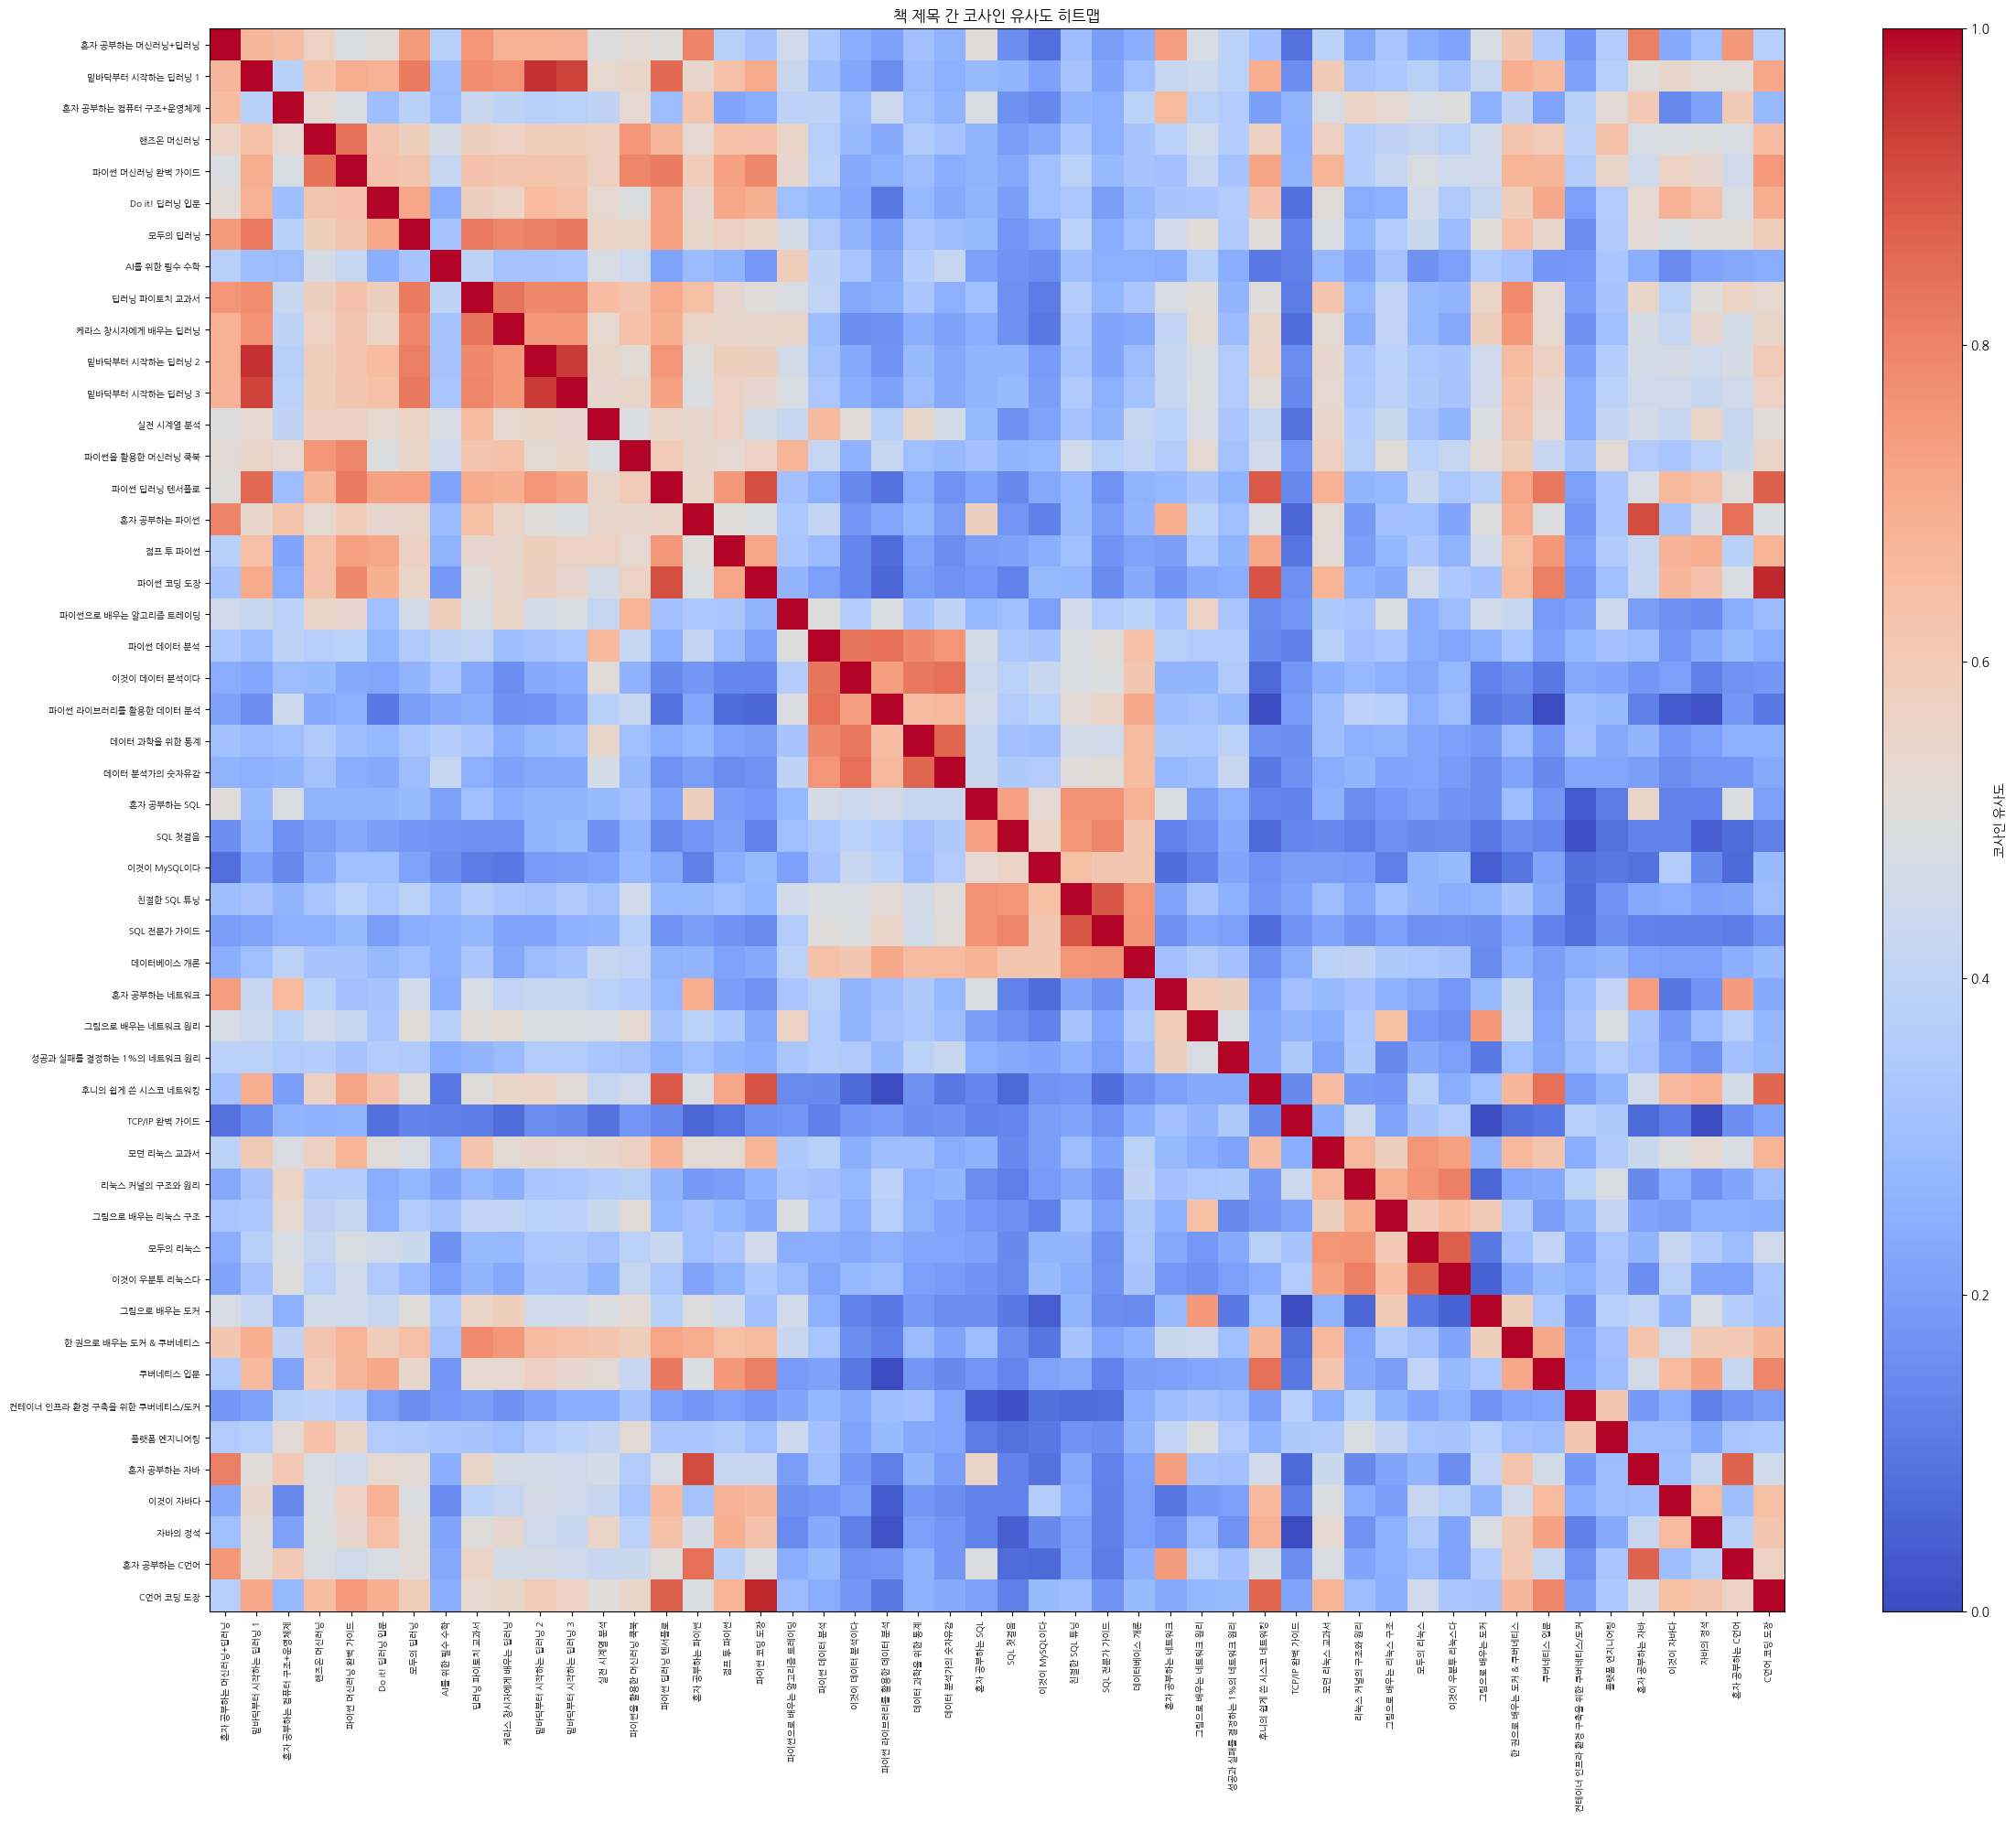

이미지 저장 완료: similarity_heatmap.png


In [15]:
# ============================================================
# 15. 책 제목 간 코사인 유사도 히트맵
# ============================================================

plt.figure(
    figsize=(24, 20)
)

image = plt.imshow(
    similarity_matrix,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    image,
    label="코사인 유사도"
)

plt.xticks(
    ticks=np.arange(len(texts)),
    labels=texts,
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=np.arange(len(texts)),
    labels=texts,
    fontsize=7
)

plt.title(
    "책 제목 간 코사인 유사도 히트맵"
)

plt.tight_layout()

plt.savefig(
    "similarity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "이미지 저장 완료: similarity_heatmap.png"
)

In [16]:
# ============================================================
# 16. 특정 책 제목과 가장 유사한 책 검색
# ============================================================

def find_similar_books(
    book_title,
    top_n=5
):
    if book_title not in texts:
        raise ValueError(
            "입력한 책 제목이 texts 목록에 없습니다."
        )

    book_index = texts.index(
        book_title
    )

    similarities = similarity_matrix[
        book_index
    ]

    sorted_indices = np.argsort(
        similarities
    )[::-1]

    results = []
    rank = 1

    for index in sorted_indices:

        if index == book_index:
            continue

        results.append(
            {
                "순위": rank,
                "책 제목": texts[index],
                "코사인 유사도": round(
                    float(similarities[index]),
                    4
                )
            }
        )

        rank += 1

        if len(results) == top_n:
            break

    return pd.DataFrame(results)

In [17]:
# ============================================================
# 17. 유사 책 검색 실행
# ============================================================

selected_book = (
    "혼자 공부하는 머신러닝+딥러닝"
)

print("기준 책:")
print(selected_book)

print("\n의미적으로 유사한 책:")

display(
    find_similar_books(
        selected_book,
        top_n=5
    )
)

기준 책:
혼자 공부하는 머신러닝+딥러닝

의미적으로 유사한 책:


,순위,책 제목,코사인 유사도
0,1,혼자 공부하는 자바,0.8120
1,2,혼자 공부하는 파이썬,0.7977
2,3,딥러닝 파이토치 교과서,0.7581
3,4,혼자 공부하는 C언어,0.7537
4,5,모두의 딥러닝,0.7436


In [18]:
# ============================================================
# 18. 새로운 검색 문장으로 의미 검색
# ============================================================

def semantic_search(
    query,
    top_n=5
):
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    query_similarities = cosine_similarity(
        query_embedding,
        embedding_array
    )[0]

    top_indices = np.argsort(
        query_similarities
    )[::-1][:top_n]

    results = []

    for rank, index in enumerate(
        top_indices,
        start=1
    ):
        results.append(
            {
                "순위": rank,
                "책 제목": texts[index],
                "코사인 유사도": round(
                    float(
                        query_similarities[index]
                    ),
                    4
                )
            }
        )

    return pd.DataFrame(results)

In [19]:
# ============================================================
# 19. 의미 검색 실행
# ============================================================

query = "인공지능과 딥러닝을 처음 공부하기 좋은 책"

print("검색 문장:")
print(query)

display(
    semantic_search(
        query,
        top_n=5
    )
)

검색 문장:
인공지능과 딥러닝을 처음 공부하기 좋은 책


,순위,책 제목,코사인 유사도
0,1,딥러닝 파이토치 교과서,0.7537
1,2,혼자 공부하는 머신러닝+딥러닝,0.6676
2,3,AI를 위한 필수 수학,0.6511
3,4,케라스 창시자에게 배우는 딥러닝,0.6275
4,5,모두의 딥러닝,0.6135


In [20]:
# ============================================================
# 20. TF-IDF 방식 검색 함수
# ============================================================

def tfidf_search(
    query,
    top_n=5
):
    query_vector = tfidf_vectorizer.transform(
        [query]
    )

    similarities = cosine_similarity(
        query_vector,
        tfidf_matrix
    )[0]

    top_indices = np.argsort(
        similarities
    )[::-1][:top_n]

    results = []

    for rank, index in enumerate(
        top_indices,
        start=1
    ):
        results.append(
            {
                "순위": rank,
                "책 제목": texts[index],
                "TF-IDF 유사도": round(
                    float(similarities[index]),
                    4
                )
            }
        )

    return pd.DataFrame(results)

In [21]:
# ============================================================
# 21. TF-IDF 검색과 임베딩 검색 비교
# ============================================================

query = "인공지능 모델을 학습하는 방법"

print("[검색 문장]")
print(query)

print("\n[TF-IDF 검색 결과]")
display(
    tfidf_search(
        query,
        top_n=5
    )
)

print("\n[임베딩 의미 검색 결과]")
display(
    semantic_search(
        query,
        top_n=5
    )
)

[검색 문장]
인공지능 모델을 학습하는 방법

[TF-IDF 검색 결과]


,순위,책 제목,TF-IDF 유사도
0,1,C언어 코딩 도장,0.0
1,2,혼자 공부하는 C언어,0.0
2,3,자바의 정석,0.0
3,4,이것이 자바다,0.0
4,5,혼자 공부하는 자바,0.0



[임베딩 의미 검색 결과]


,순위,책 제목,코사인 유사도
0,1,파이썬으로 배우는 알고리즘 트레이딩,0.7123
1,2,AI를 위한 필수 수학,0.7016
2,3,그림으로 배우는 네트워크 원리,0.5485
3,4,파이썬을 활용한 머신러닝 쿡북,0.4958
4,5,실전 시계열 분석,0.4869


In [22]:
# ============================================================
# 22. 생성된 결과 파일 다운로드
# ============================================================

from google.colab import files

files.download(
    "embeddings.tsv"
)

files.download(
    "metadata.tsv"
)

files.download(
    "similarity_heatmap.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>